### Import Nesseccery libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error

### Load Dataset

In [2]:
df = pd.read_excel('premiums.xlsx')
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [3]:
df.shape

(50000, 13)

### Handle Null values

In [4]:
df.isnull().sum()

Age                       0
Gender                    0
Region                    0
Marital_status            0
Number Of Dependants      0
BMI_Category              0
Smoking_Status           11
Employment_Status         2
Income_Level             13
Income_Lakhs              0
Medical History           0
Insurance_Plan            0
Annual_Premium_Amount     0
dtype: int64

In [5]:
# Drop them because less

df.dropna(inplace = True)

In [6]:
df.isnull().sum()

Age                      0
Gender                   0
Region                   0
Marital_status           0
Number Of Dependants     0
BMI_Category             0
Smoking_Status           0
Employment_Status        0
Income_Level             0
Income_Lakhs             0
Medical History          0
Insurance_Plan           0
Annual_Premium_Amount    0
dtype: int64

### Handle Inconsistent column naming

In [7]:
# Make the column naming consistent
df.columns = df.columns.str.replace(" ", "_").str.lower()
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='object')

In [8]:
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


### Overview of numeric columns of dataset

In [9]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.591764,1.711842,23.021150,15766.810189
std,15.000378,1.498195,24.221794,8419.995271
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,356.000000,5.000000,930.000000,43471.000000


There are outliers present in this dataset. Let's handle them as well.

### Outlier Treatment

In [10]:
# Let's create boxplot of every numeric column to find outliers

numeric_columns = df.select_dtypes(['int64','float64']).columns # getting numeric columns
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

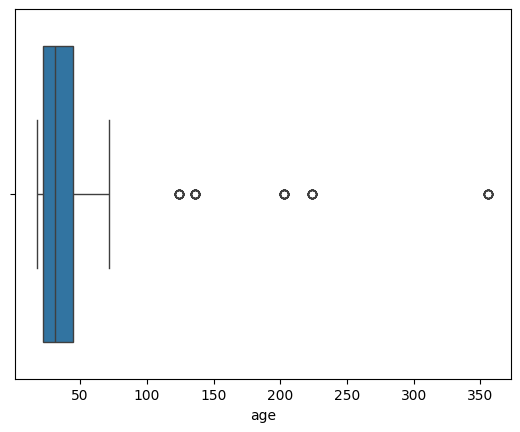

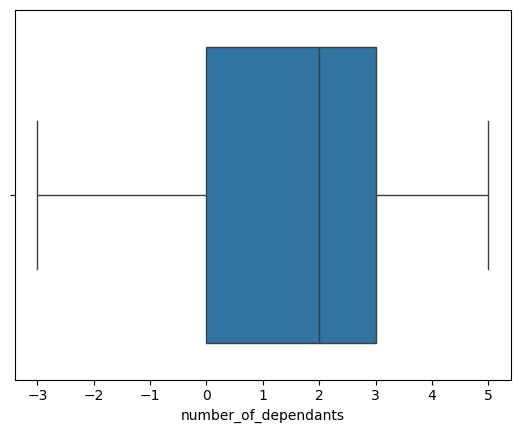

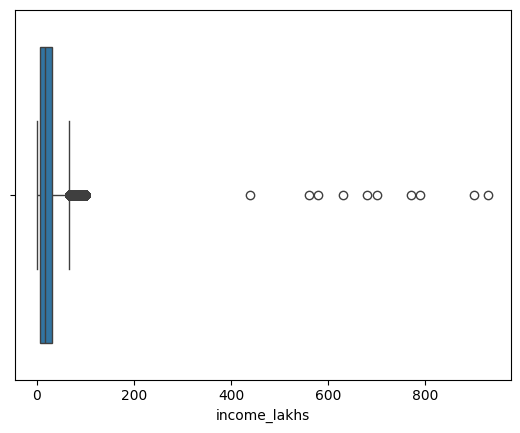

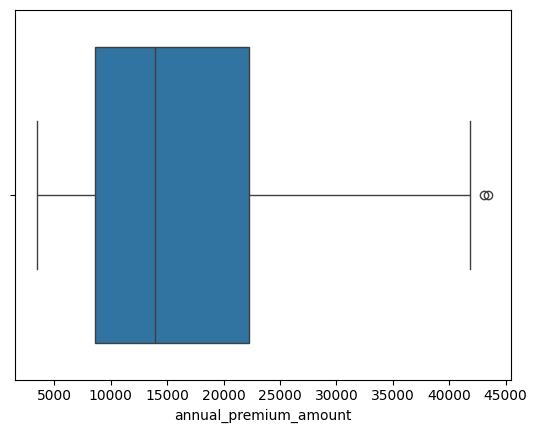

In [11]:
# Creating boxplot
for col in numeric_columns:
    sns.boxplot(x = df[col])
    plt.show()

In [12]:
# No of dependents can't be negative
df[df.number_of_dependants < 0].head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
402,23,Female,Southwest,Unmarried,-3,Underweight,No Smoking,Freelancer,10L - 25L,18,No Disease,Silver,9309
2245,18,Male,Southwest,Unmarried,-3,Overweight,No Smoking,Freelancer,25L - 40L,28,No Disease,Silver,8095
2323,19,Male,Northwest,Unmarried,-3,Underweight,No Smoking,Freelancer,25L - 40L,40,No Disease,Bronze,4641
2986,34,Female,Southeast,Married,-1,Underweight,Regular,Self-Employed,25L - 40L,35,High blood pressure & Heart disease,Silver,22995
3756,41,Male,Southwest,Married,-1,Obesity,Regular,Salaried,10L - 25L,21,Diabetes,Silver,22766


In [13]:
# Make this column absolute
df['number_of_dependants'] = abs(df['number_of_dependants'])
df.number_of_dependants.describe()

count    49976.000000
mean         1.717284
std          1.491953
min          0.000000
25%          0.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: number_of_dependants, dtype: float64

In [14]:
# Age has certain outliers

df[df.age > 100].shape # Taking 100 as a threshold

(58, 13)

In [15]:
# There are very few values (58 out of 50000) so we can simply remove them
df1 = df[df.age <= 100].copy()
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49918.000000,49918.000000,49918.000000,49918.000000
mean,34.401839,1.717617,23.025141,15766.589286
std,13.681600,1.492074,24.227912,8419.137327
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22272.000000
max,72.000000,5.000000,930.000000,43471.000000


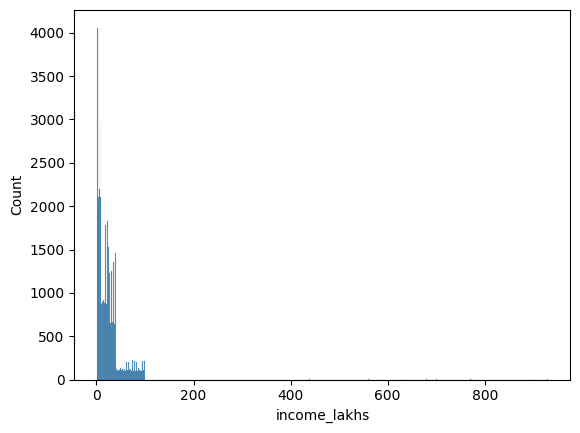

In [16]:
# Income column is probably skewed let's verify it using histogram
sns.histplot(df1.income_lakhs)
plt.show()

As you can see it is highly skewed. let's treat the outliers using IQR method

In [17]:
# Creating function for getting bounds
def get_bounds(col):
    Q1, Q3 = col.quantile([0.25,0.75])
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

In [18]:
lower, upper = get_bounds(df1.income_lakhs)
lower, upper

(-29.0, 67.0)

The upper bound is 67 lakh but don't use it blindly using common sense and business knowledge we know what people even earns more than 1 crore a year.

So Let's take upper bound as 100 and find out how many users are more than that

In [19]:
df1[df1.income_lakhs > 100] 

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
2635,51,Male,Northwest,Married,4,Obesity,No Smoking,Self-Employed,> 40L,560,High blood pressure,Gold,30692
4220,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,440,No Disease,Silver,10636
7775,35,Female,Northeast,Unmarried,0,Overweight,No Smoking,Salaried,> 40L,630,Diabetes,Gold,24010
9021,43,Male,Southeast,Married,3,Obesity,Regular,Salaried,> 40L,900,Diabetes & Thyroid,Gold,30848
10337,37,Female,Southeast,Married,3,Normal,No Smoking,Freelancer,> 40L,930,Diabetes,Silver,15945
10639,20,Female,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,> 40L,580,Thyroid,Silver,12888
11456,21,Female,Southwest,Unmarried,0,Obesity,No Smoking,Freelancer,> 40L,700,No Disease,Bronze,7424
15437,21,Female,Southeast,Unmarried,0,Normal,Occasional,Salaried,> 40L,790,No Disease,Silver,7586
35446,59,Male,Northwest,Married,2,Obesity,Occasional,Self-Employed,> 40L,770,Thyroid,Gold,31115
40970,48,Male,Northeast,Married,4,Obesity,No Smoking,Salaried,> 40L,680,No Disease,Gold,28926


Very few. So we can safely remove them.

In [20]:
df2 = df1[df1.income_lakhs <= 100].copy()
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49908.000000,49908.000000,49908.000000,49908.000000
mean,34.401579,1.717640,22.889897,15765.739641
std,13.681604,1.492032,22.170699,8418.674061
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22270.500000
max,72.000000,5.000000,100.000000,43471.000000


Let's verify the outlier treatment by again plotting histogram.

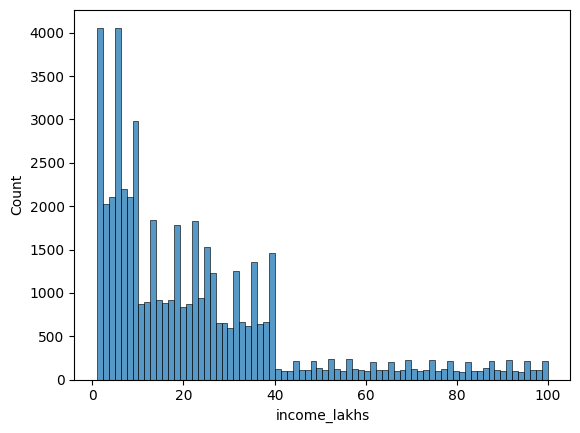

In [21]:
sns.histplot(df2.income_lakhs)
plt.show()

The histogram looks much better now.

So the outlier treatment is complete.

### Visualization

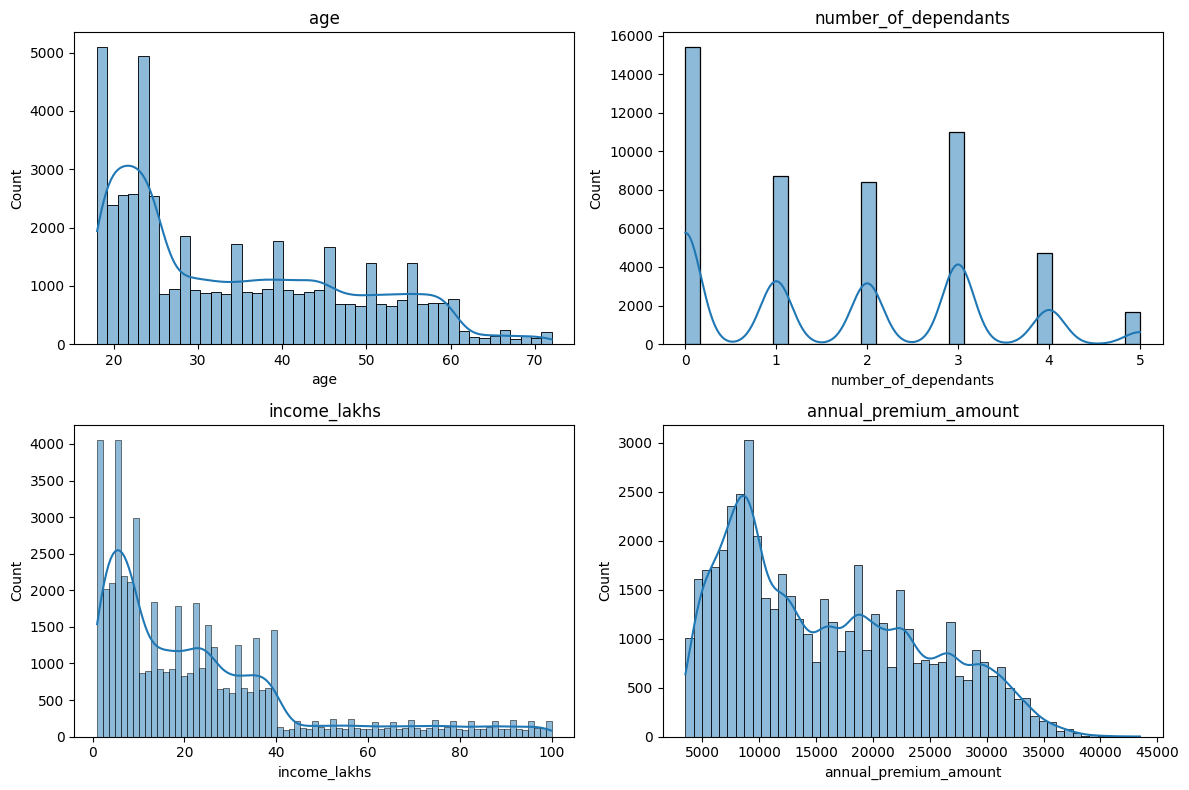

In [22]:
# Let's visualize numeric columns using histogram

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Flatten the 2x2 array of axes into a 1D list
axes = axes.flatten()

for i, col in enumerate(numeric_columns[:4]):
    sns.histplot(data=df2, x=col, ax=axes[i], kde=True)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

This is called univariate analysis, here we are analysing only one variable.

Let's do bivariate analysis using scatterplot with our target variable which is annual premium amount.

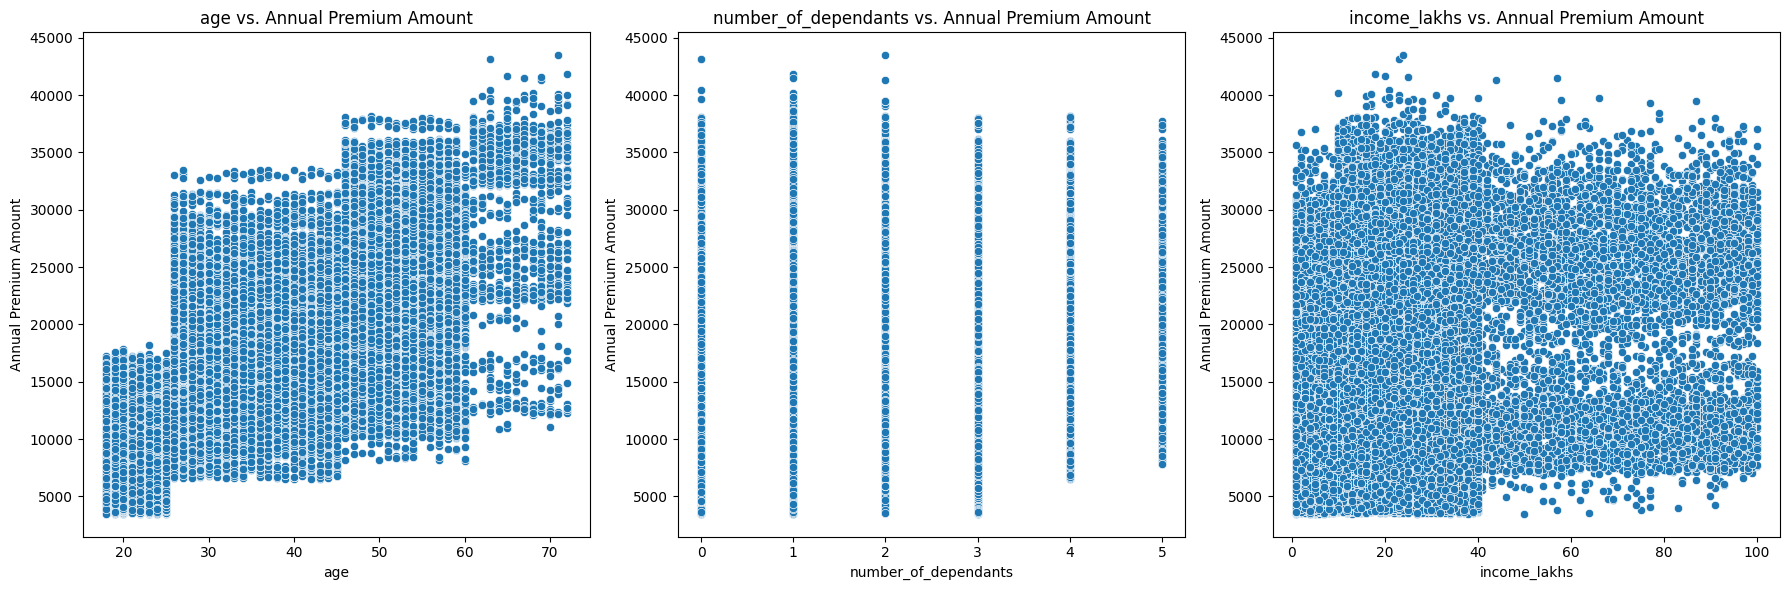

In [23]:
cols = ['age', 'number_of_dependants','income_lakhs']

fig, axes = plt.subplots(1, len(cols), figsize =(18,6))

for ax, col in zip(axes, cols):
    sns.scatterplot(df2, x=col, y ='annual_premium_amount', ax=ax)
    ax.set_title(f'{col} vs. Annual Premium Amount')
    ax.set_xlabel(col)
    ax.set_ylabel('Annual Premium Amount')

plt.tight_layout()
plt.show()

### Categorical Columns

In [24]:
categorical_columns = df2.select_dtypes(['object']).columns
categorical_columns

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [25]:
# Let's print unique values of each of this column
for col in categorical_columns:
    print(col, df2[col].unique())

gender ['Male' 'Female']
region ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status ['Unmarried' 'Married']
bmi_category ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status ['No Smoking' 'Regular' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status ['Salaried' 'Self-Employed' 'Freelancer']
income_level ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan ['Bronze' 'Silver' 'Gold']


As you can see there are duplicate values in smoking status column let's handle that.

In [26]:
df2['smoking_status'] = df2['smoking_status'].replace({
    'Smoking=0' : 'No Smoking',
    'Does Not Smoke' : 'No Smoking',
    'Not Smoking' : 'No Smoking'
})

# let's verify 
df2['smoking_status'].unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

Now let's do univariate analysis on categorical columns as well.

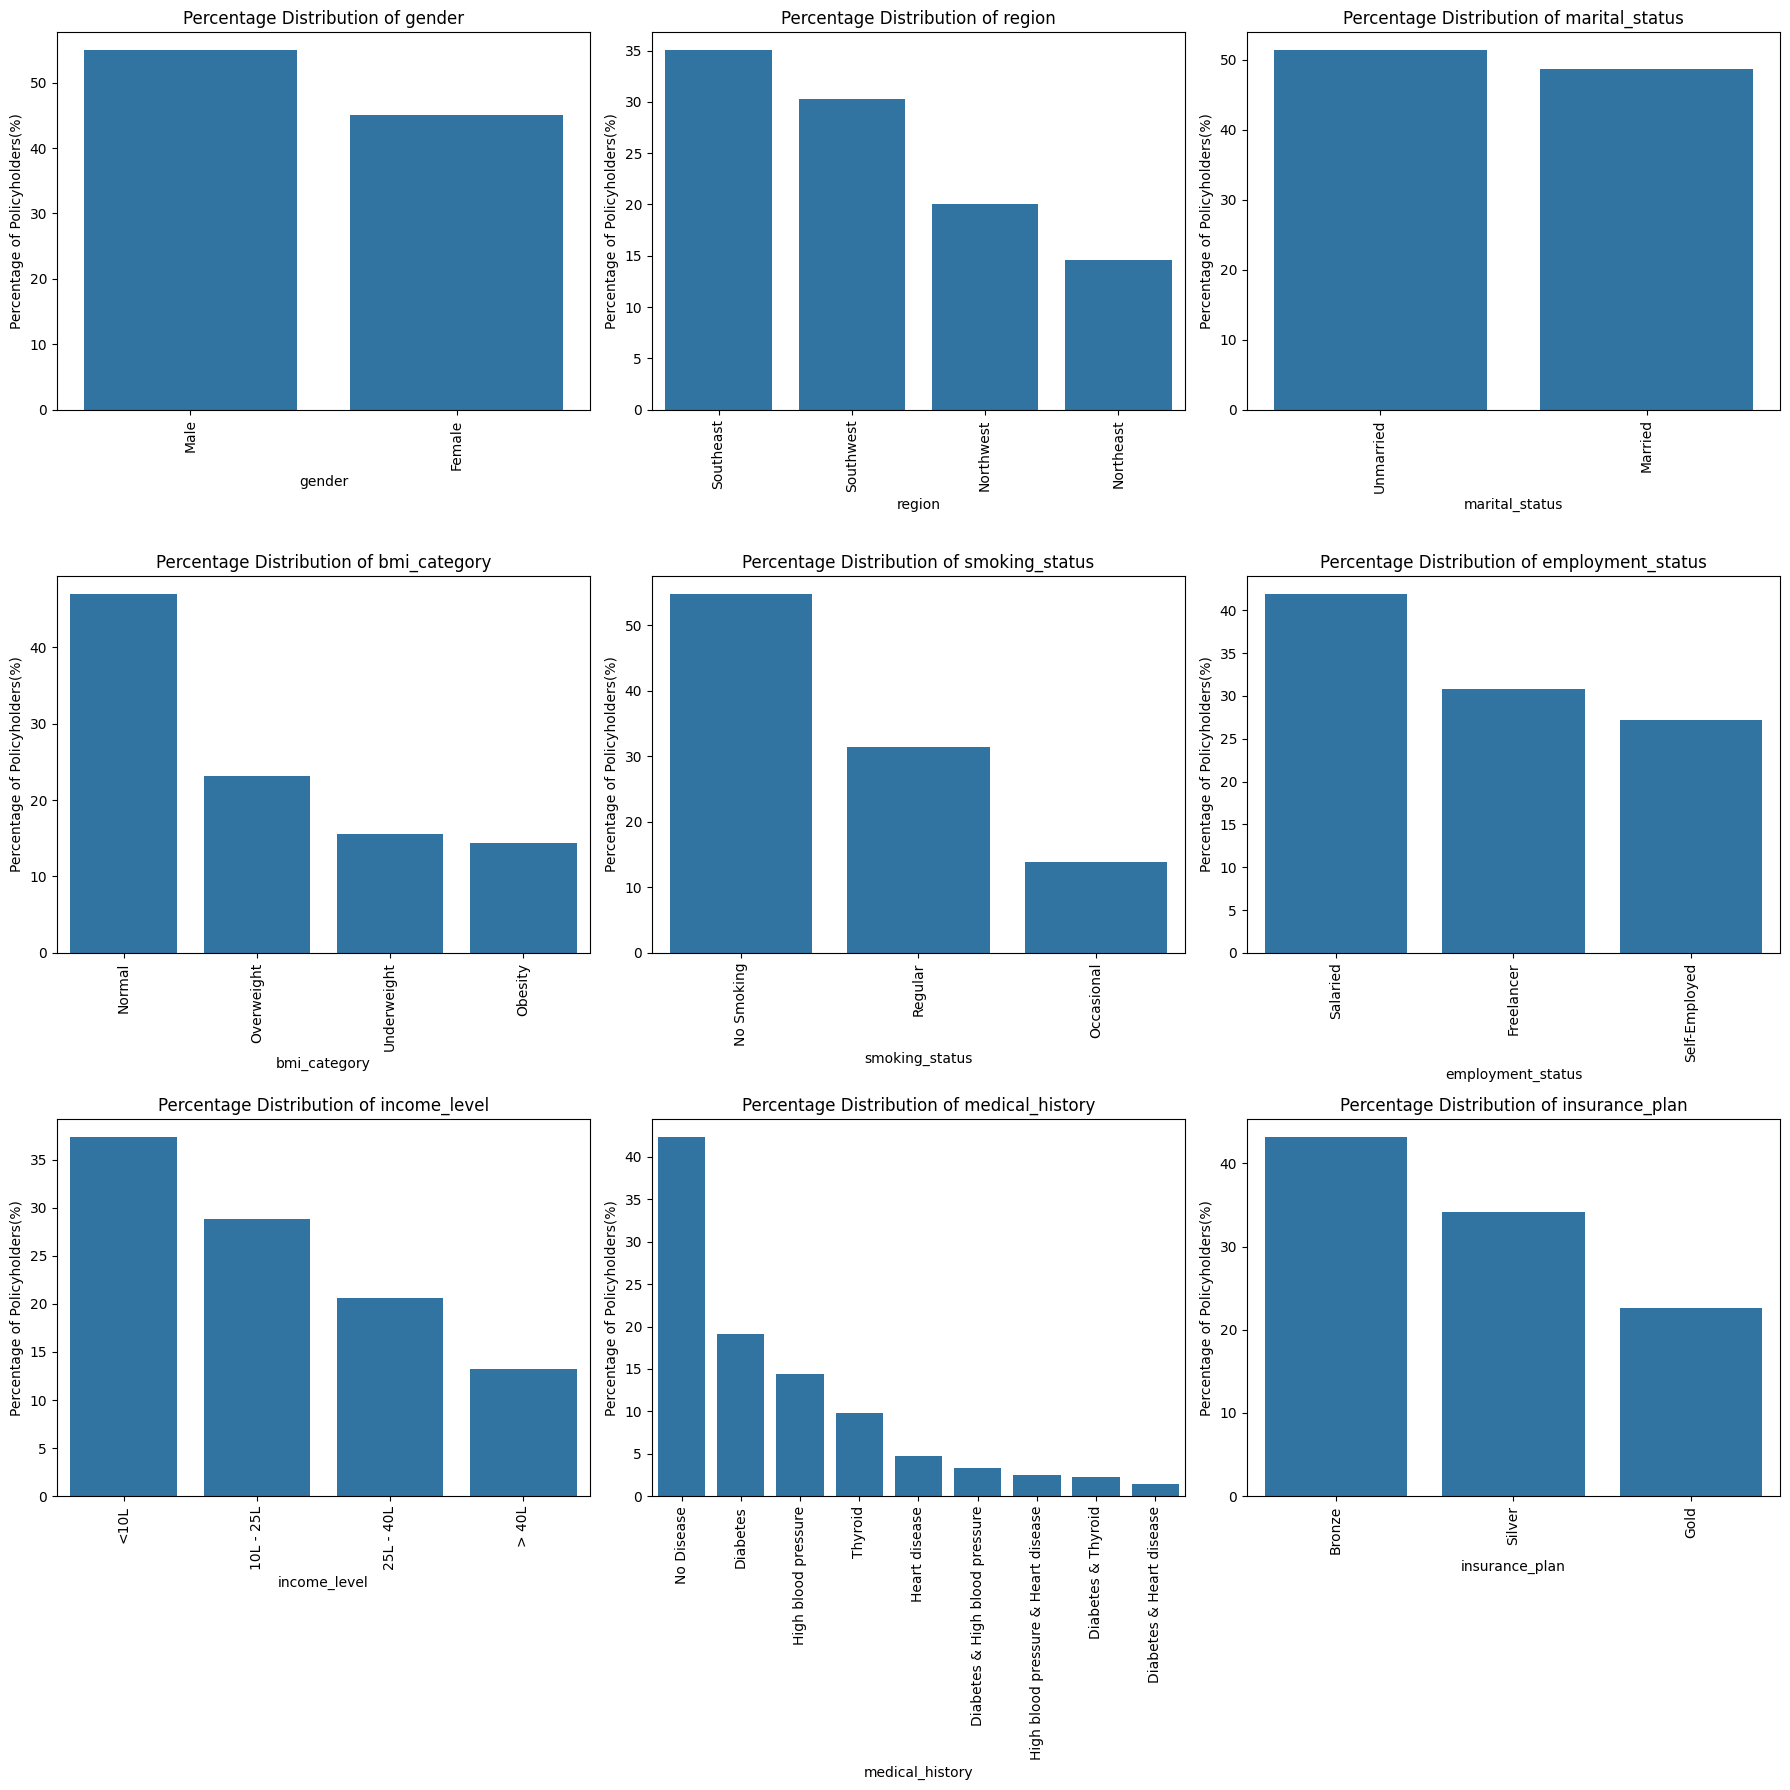

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(18,18))
axes = axes.flatten()

for ax, col in zip(axes, categorical_columns):
    category_counts = df2[col].value_counts(normalize = True) * 100

    # plotting the distribution using barplot
    sns.barplot(x = category_counts.index, y = category_counts.values, ax = ax)
    ax.set_title(f'Percentage Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Percentage of Policyholders(%)')
    ax.tick_params(axis='x', rotation=90)
    
plt.tight_layout()
plt.show()

Now let's do bivariate analysis on categorical columns too.

For that we will use pandas method called crosstab.

In [28]:
crosstab = pd.crosstab(df2['income_level'], df2['insurance_plan'])
crosstab

insurance_plan,Bronze,Gold,Silver
income_level,,,
10L - 25L,5307,3880,5182
25L - 40L,3683,2840,3750
<10L,12226,931,5486
> 40L,329,3653,2641


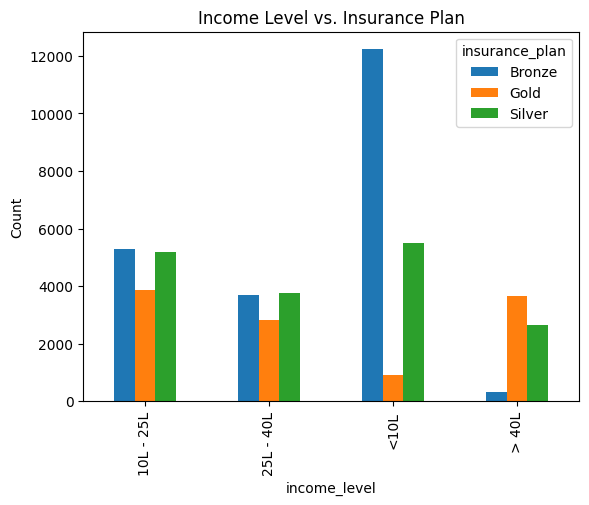

In [29]:
# Let's visualize this using bar plot
crosstab.plot(kind = 'bar')
plt.title('Income Level vs. Insurance Plan')
plt.ylabel('Count')
plt.show()

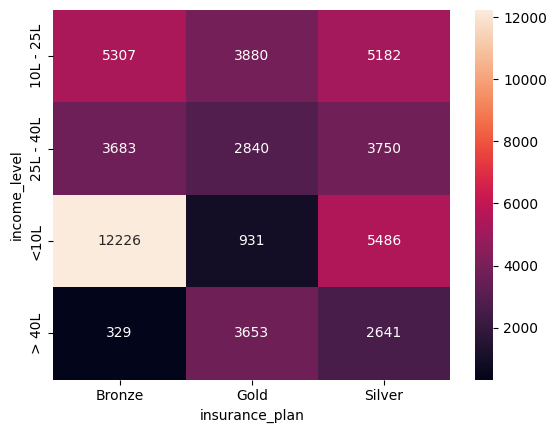

In [30]:
# We can visualize it using heatmap as well
sns.heatmap(crosstab, annot = True, fmt='d')
plt.show()

### Feature Engineering

In [31]:
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [32]:
# Let's see medical history unique values 
df2.medical_history.unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

Now our model can't understand these values directly it only undertands numbers. Now if the person has more serious disease the risk score will be higher. So our insurance company provided risk score based on the medical condition.

In [33]:
# Risk scores
risk_scores = {
    'diabetes' : 6,
    'heart disease' : 8,
    'high blood pressure' : 6,
    'thyroid' : 5,
    'no disease' : 0,
    'none' : 0
}

df2[['disease1', 'disease2']] = df2['medical_history'].str.split(' & ', expand = True).apply(lambda x : x.str.lower())
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,None
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,None
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,high blood pressure,None
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,no disease,None
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,high blood pressure,None


Now all the values are ready to mapped with the score provided by company but None also should be in lower case let's replace null values also with none.


In [34]:
df2['disease1'] = df2['disease1'].fillna('none')
df2['disease2'] = df2['disease2'].fillna('none')
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,none
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,none
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,high blood pressure,none
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,no disease,none
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,high blood pressure,none


In [35]:
# Now let's create tota_risk_score which will be total score 
df2['total_risk_score'] = 0

for disease in ['disease1', 'disease2']:
    df2['total_risk_score'] += df2[disease].map(risk_scores)

df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,none,6
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,none,6
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,high blood pressure,none,6
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,no disease,none,0
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,high blood pressure,none,6


In [36]:
# Now let's normalize it using min max method
max_score = df2['total_risk_score'].max()
min_score = df2['total_risk_score'].min()
df2['normalized_risk_score'] = (df2['total_risk_score'] - min_score)/ (max_score - min_score)
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,no disease,none,0,0.000000
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,high blood pressure,none,6,0.428571


In [37]:
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,no disease,none,0,0.000000
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,high blood pressure,none,6,0.428571


In [38]:
# Ordinal Encoding
df2['insurance_plan'].unique()

array(['Bronze', 'Silver', 'Gold'], dtype=object)

This one is a ordinal column so we will handle it using simple label encoding.

In [39]:
df2['insurance_plan'] = df2['insurance_plan'].map({'Bronze' : 1, 'Silver' : 2, 'Gold' : 3})
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,1,9053,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,1,16339,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,2,18164,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,3,20303,no disease,none,0,0.000000
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,2,13365,high blood pressure,none,6,0.428571


Same with income level column

In [40]:
df2['income_level'] = df2['income_level'].map({'<10L' : 1, '10L - 25L' : 2, '25L - 40L' : 3, '> 40L' : 4})
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,1,6,Diabetes,1,9053,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,1,6,Diabetes,1,16339,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,2,20,High blood pressure,2,18164,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,4,77,No Disease,3,20303,no disease,none,0,0.000000
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,4,99,High blood pressure,2,13365,high blood pressure,none,6,0.428571


In [41]:
# Nominal Encoding
nom_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']
df3 = pd.get_dummies(data= df2, columns = nom_cols, drop_first=True, dtype = int).copy()
df3.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,diabetes,none,6,...,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,diabetes,none,6,...,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,high blood pressure,none,6,...,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,No Disease,3,20303,no disease,none,0,...,1,0,0,0,0,0,0,0,1,0
4,18,0,4,99,High blood pressure,2,13365,high blood pressure,none,6,...,0,0,1,0,1,0,0,1,0,1


In [42]:
# Let's drop columns that are not needed anymore
df4 = df3.drop(['medical_history', 'disease1', 'disease2', 'total_risk_score'], axis = 1).copy()
df4.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,3,20303,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,18,0,4,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1


### Correlation Analysis

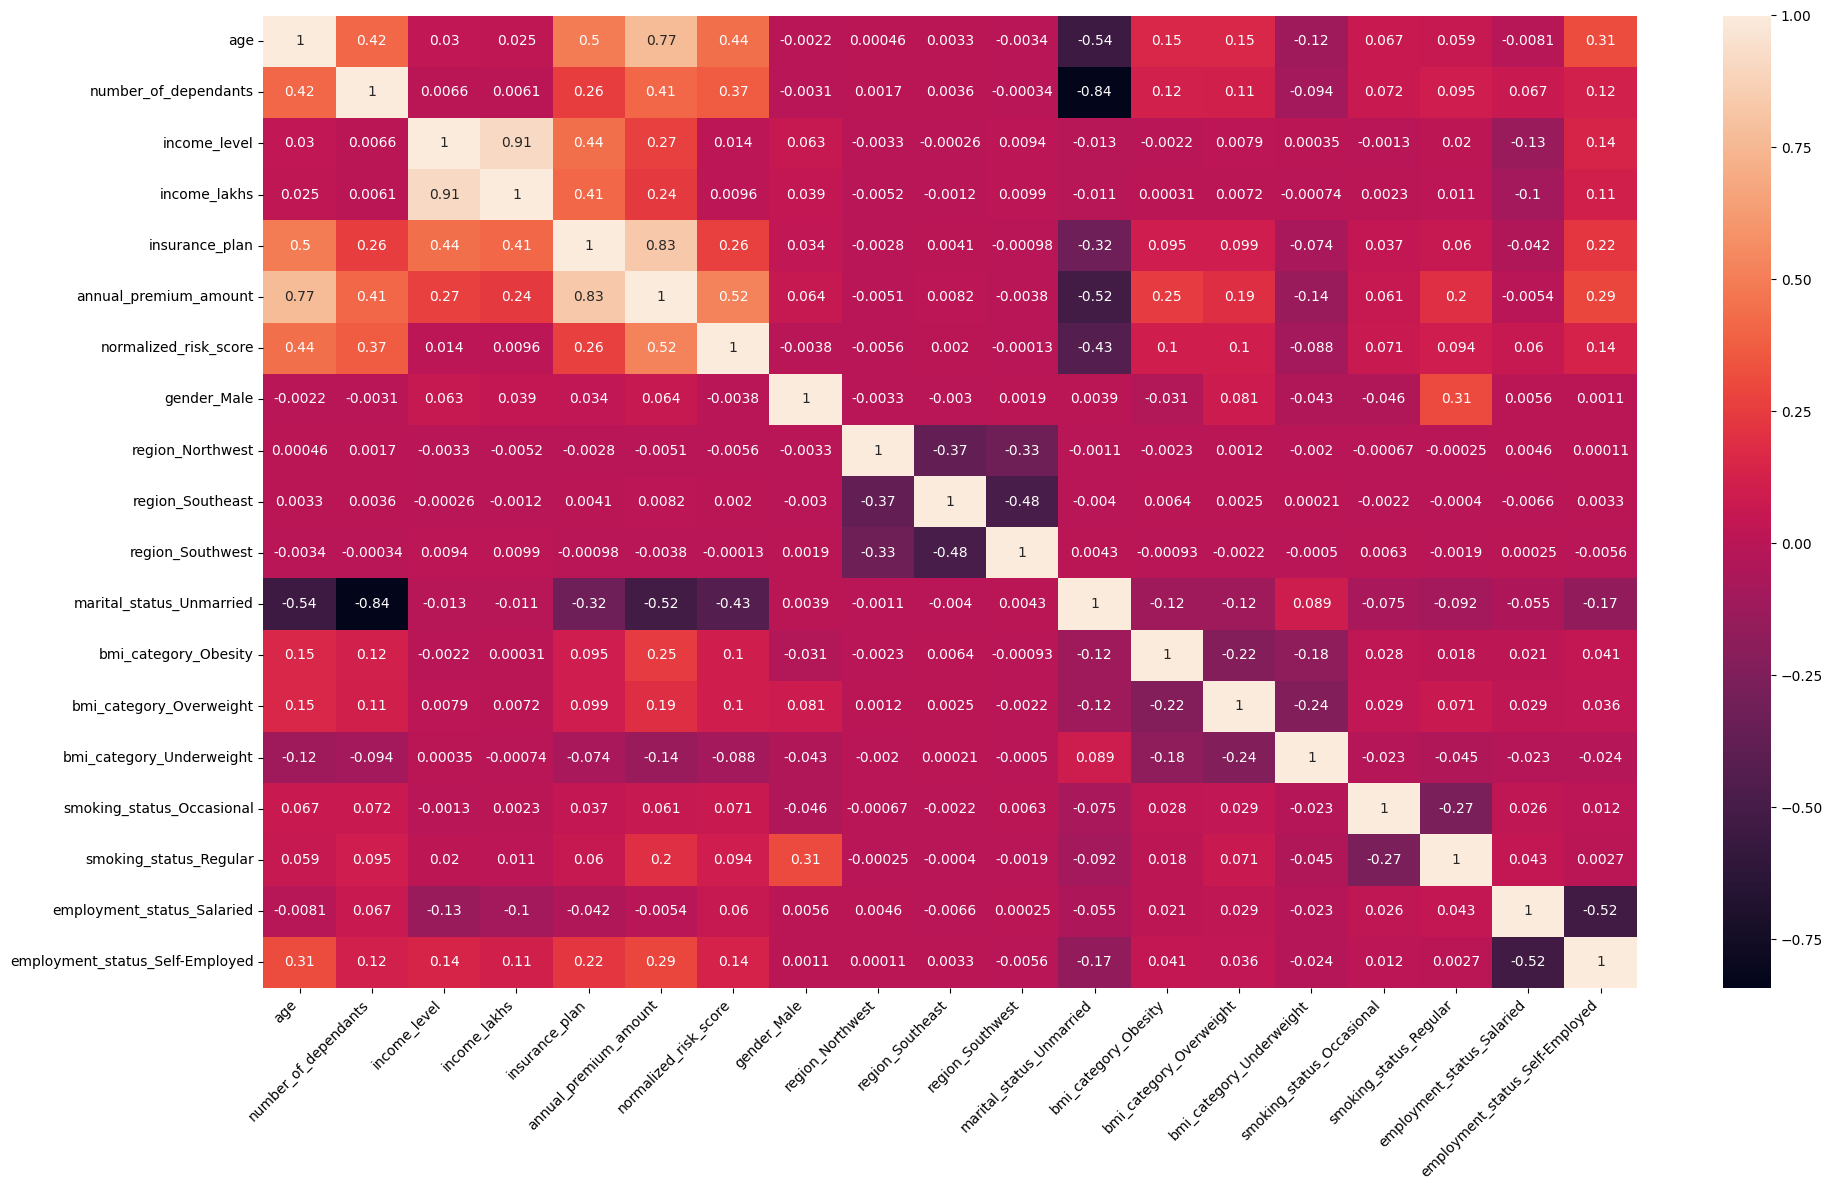

In [43]:
cm = df4.corr()

plt.figure(figsize = (20,12))
sns.heatmap(cm, annot = True)
plt.xticks(rotation = 45, ha = 'right')
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()

In [44]:
df4.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.00000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000
mean,34.401579,1.717640,2.097700,22.889897,1.794802,15765.739641,0.291831,0.549631,0.20093,0.350385,0.303038,0.513545,0.143183,0.231245,0.155326,0.138274,0.313857,0.419412,0.272041
std,13.681604,1.492032,1.049133,22.170699,0.784919,8418.674061,0.287420,0.497536,0.40070,0.477095,0.459576,0.499822,0.350263,0.421633,0.362219,0.345191,0.464064,0.493468,0.445015
min,18.000000,0.000000,1.000000,1.000000,1.000000,3501.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,1.000000,7.000000,1.000000,8608.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,31.000000,2.000000,2.000000,17.000000,2.000000,13928.000000,0.357143,1.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,45.000000,3.000000,3.000000,31.000000,2.000000,22270.500000,0.428571,1.000000,0.00000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,72.000000,5.000000,4.000000,100.000000,3.000000,43471.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [45]:
# Let's create now our feature and target variables
X = df4.drop('annual_premium_amount', axis = 1)
y = df4['annual_premium_amount']

# Let's scale numeric values using MinMax scaler now
cols_to_scale = ['age', 'number_of_dependants', 'income_level', 'income_lakhs', 'insurance_plan']
scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.148148,0.0,0.000000,0.050505,0.0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,0.203704,0.4,0.000000,0.050505,0.0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,0.574074,0.4,0.333333,0.191919,0.5,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,0.222222,0.6,1.000000,0.767677,1.0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,0.000000,0.0,1.000000,0.989899,0.5,0.428571,1,0,0,0,1,0,1,0,0,1,0,1


In [46]:
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.00000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000
mean,0.303733,0.343528,0.365900,0.221110,0.397401,0.291831,0.549631,0.20093,0.350385,0.303038,0.513545,0.143183,0.231245,0.155326,0.138274,0.313857,0.419412,0.272041
std,0.253363,0.298406,0.349711,0.223946,0.392459,0.287420,0.497536,0.40070,0.477095,0.459576,0.499822,0.350263,0.421633,0.362219,0.345191,0.464064,0.493468,0.445015
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.074074,0.000000,0.000000,0.060606,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.240741,0.400000,0.333333,0.161616,0.500000,0.357143,1.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.500000,0.600000,0.666667,0.303030,0.500000,0.428571,1.000000,0.00000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Now all the features are nicely scaled.So now we can compute VIF.

In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Function to calculate VIF
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values, i ) for i in range(data.shape[1])]
    return vif_df

In [48]:
calculate_vif(X)

,Column,VIF
0,age,4.567634
1,number_of_dependants,4.534650
2,income_level,12.450675
3,income_lakhs,11.183367
4,insurance_plan,3.584752
5,normalized_risk_score,2.687610
6,gender_Male,2.421496
7,region_Northwest,2.102556
8,region_Southeast,2.922414
9,region_Southwest,2.670666


Usually we start by removing the column with VIF > 10 and calculate VIF again at each step and stop removing column when no column has VIF > 10.

So here income level has highest VIF. Let's remove that first and calculate VIF again.

In [49]:
calculate_vif(X.drop('income_level', axis = 1))

,Column,VIF
0,age,4.545825
1,number_of_dependants,4.526598
2,income_lakhs,2.480563
3,insurance_plan,3.445682
4,normalized_risk_score,2.687326
5,gender_Male,2.409980
6,region_Northwest,2.100789
7,region_Southeast,2.919775
8,region_Southwest,2.668314
9,marital_status_Unmarried,3.393718


As you can see now all the VIFs are within range of 5 so we are good to go and there is no two highly correlated columns are present in this now.

In [50]:
# Let's create X_reduced which is X without income_level column
X_reduced = X.drop('income_level', axis = 1)
X_reduced.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.148148,0.0,0.050505,0.0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,0.203704,0.4,0.050505,0.0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,0.574074,0.4,0.191919,0.5,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,0.222222,0.6,0.767677,1.0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,0.000000,0.0,0.989899,0.5,0.428571,1,0,0,0,1,0,1,0,0,1,0,1


### Model Training

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.3, random_state=10)

# Numbers of columns in each
print(f'X train: {X_train.shape}')
print(f'X test: {X_test.shape}')
print(f'y train: {y_train.shape}')
print(f'y test: {y_test.shape}')

X train: (34935, 17)
X test: (14973, 17)
y train: (34935,)
y test: (14973,)


In [52]:
# Linear Regression
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
train_score = model_lr.score(X_train, y_train)
test_score = model_lr.score(X_test, y_test)
train_score, test_score

(0.9282143576916762, 0.9280547230217837)

For Linear Regression model we are getting score around 92% in both train and test data.

In [53]:
y_pred = model_lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = root_mean_squared_error(y_test, y_pred)

print("Linear Regression => MSE :", mse_lr, "RMSE:", rmse_lr)

Linear Regression => MSE : 5165611.913027982 RMSE: 2272.798256121291


In [54]:
# Let's calculate the model's coefficient and the intercept
coef = model_lr.coef_
inter = model_lr.intercept_
coef, inter

(array([11160.92646188,  -676.44399066,  -514.22981577, 12557.01293645,
         4810.35770228,   168.64666183,   -35.7192924 ,    39.96512973,
          -24.65292857,  -935.76061134,  3387.91145477,  1599.36226775,
          391.1713038 ,   735.91227798,  2234.8047119 ,   155.9846743 ,
          415.90397305]),
 4824.300272127104)

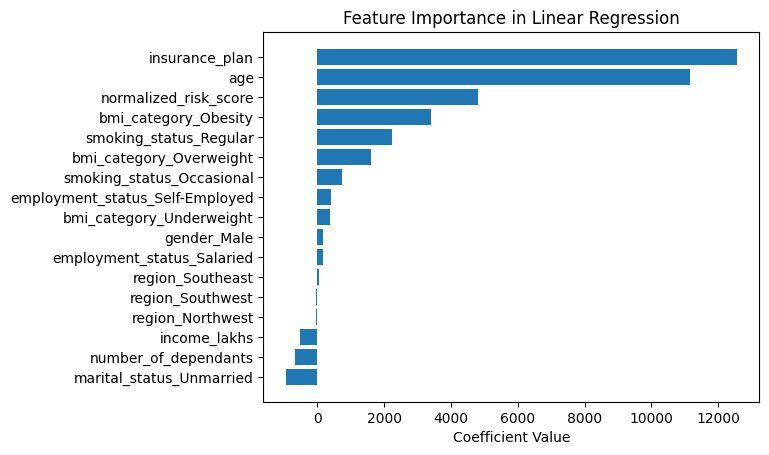

In [55]:
# let's calculate feature importance using coef
feature_importance = model_lr.coef_

# In order to create bar chart we need to create temp dataframe for the feature importances
coef_df = pd.DataFrame(feature_importance, index=X_test.columns ,columns=['Coefficients'] )
coef_df = coef_df.sort_values(by = 'Coefficients', ascending = True)

# Let's plot bar chart now to visualize feature importances
plt.barh(coef_df.index, coef_df['Coefficients'])
plt.xlabel('Coefficient Value')
plt.title("Feature Importance in Linear Regression")
plt.show()

Now let's try Lasso model to see if we get any improvement.

In [56]:
# Lasso Regression 
model_lasso = Lasso()
model_lasso.fit(X_train, y_train)
train_score = model_lasso.score(X_train, y_train)
test_score = model_lasso.score(X_test, y_test)
train_score, test_score

(0.928211327505007, 0.9280870828363261)

In [57]:
y_pred = model_lasso.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred)
rmse_lasso = root_mean_squared_error(y_test, y_pred)

print("Lasso Regression => MSE :", mse_lasso, "RMSE:", rmse_lasso)

Lasso Regression => MSE : 5163288.504869386 RMSE: 2272.2870648026374


We are getting simillar scores for Lasso model as well, So let's try the XGBoost regressor model to see if we get any improvements.

In [58]:
# XGBoost Regressor
model_xgb = XGBRegressor()
model_xgb.fit(X_train, y_train)
train_score = model_xgb.score(X_train, y_train)
test_score = model_xgb.score(X_test, y_test)
train_score, test_score

(0.9861524105072021, 0.9809137582778931)

As you can see, XGBoost model is giving solid 98% score which is far better than Linear Regression or Lasso model.

Let's also check MSE and RMSE

In [59]:
y_pred = model_xgb.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred)
rmse_xgb = root_mean_squared_error(y_test, y_pred)

print("XGBoost Regression => MSE :", mse_xgb, "RMSE:", rmse_xgb)

XGBoost Regression => MSE : 1370377.0 RMSE: 1170.6309814453125


Let's do Randomized Search on our XGBoost model to make sure that it works with same accuracy for all kind of splits and to find best params for our model.

In [60]:
model_xgb = XGBRegressor()
param_grid = {
    'n_estimators' : [20,40,50],
    'learning_rate' : [0.01, 0.1, 0.2],
    'max_depth' : [3, 4, 5],
}

random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter=10, cv = 3, scoring='r2', random_state=42)
random_search.fit(X_train, y_train)
random_search.best_score_

0.9808828632036845

Let's checkout the best params now.

In [61]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}

In [62]:
# Store Best Model
best_model = random_search.best_estimator_

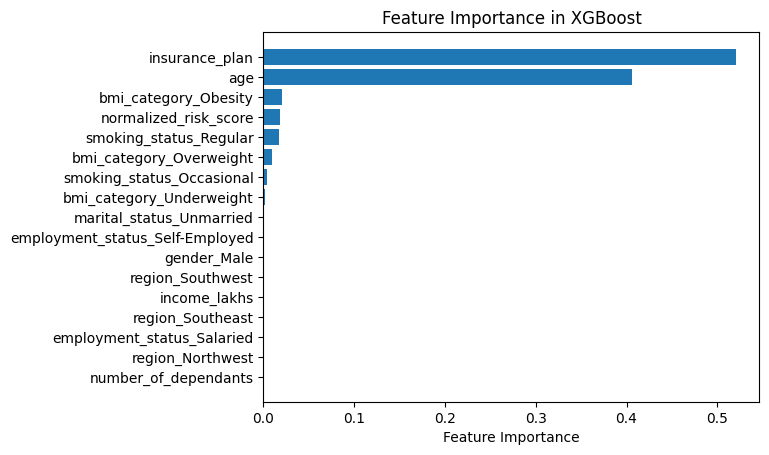

In [63]:
# let's calculate feature importance
feature_importance = best_model.feature_importances_

# In order to create bar chart we need to create temp dataframe for the feature importances
coef_df = pd.DataFrame(feature_importance, index=X_test.columns ,columns=['Coefficients'] )
coef_df = coef_df.sort_values(by = 'Coefficients', ascending = True)

# Let's plot bar chart now to visualize feature importances
plt.barh(coef_df.index, coef_df['Coefficients'])
plt.xlabel('Feature Importance')
plt.title("Feature Importance in XGBoost")
plt.show()

Note: Feature importance in XGBoost may not be as straightforward to interpret as feature importance in Linear Regression, since XGBoost is a tree-based model.

### Error Analysis

In [64]:
y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residuals_pct = residuals*100/y_test

results_df = pd.DataFrame({
    'actual' : y_test,
    'predicted' : y_pred,
    'diff' : residuals,
    'diff_pct' : residuals_pct
})

results_df

,actual,predicted,diff,diff_pct
3598,20554,20307.691406,-246.308594,-1.198349
35794,29647,29078.191406,-568.808594,-1.918604
43608,20560,20597.792969,37.792969,0.183818
42730,5018,7050.571777,2032.571777,40.505615
18936,8929,8171.252441,-757.747559,-8.486365
...,...,...,...,...
5621,18848,18554.957031,-293.042969,-1.554770
6069,6956,6483.342285,-472.657715,-6.794964
21592,8332,10583.080078,2251.080078,27.017284
49274,5571,6753.666504,1182.666504,21.228981


Let's visualize using histogram that how much error perecentage do we have across all records.

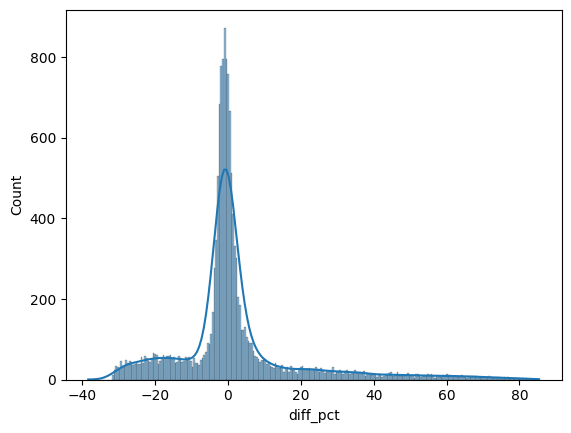

In [65]:
sns.histplot(results_df.diff_pct, kde = True)
plt.show()

As you can see most of the records are between -10 to 10% error margin but some of them are horrible like more than 80% error margin.

We have decided out extreme error threshold to be 10% on the both sides.

So now let's check how many records do have which has more than 10% error margin (on both ends).

In [66]:
extreme_error_threshold = 10
extreme_results_df = results_df[np.abs(results_df.diff_pct) > extreme_error_threshold]
extreme_results_df.shape

(4498, 4)

In [67]:
results_df.shape

(14973, 4)

In [68]:
# Let's calculate percentage now
extreme_errors_pct = (extreme_results_df.shape[0]*100)/results_df.shape[0]
extreme_errors_pct

30.04073999866426

So as you can see that our 30% of predictions are extreme errors(Where the error margin is more than 10%).

In [69]:
# Let's check how many records has too high error margin(more than 50%)
results_df[np.abs(results_df.diff_pct) > 50].sort_values('diff_pct', ascending = False)

,actual,predicted,diff,diff_pct
36269,3501,6490.080566,2989.080566,85.377908
48801,3516,6490.080566,2974.080566,84.587047
42342,3521,6490.080566,2969.080566,84.324924
18564,3523,6483.342285,2960.342285,84.029017
7988,3527,6483.342285,2956.342285,83.820309
...,...,...,...,...
48974,4314,6483.342285,2169.342285,50.286098
28867,4665,7007.325684,2342.325684,50.210626
27859,5162,7753.431152,2591.431152,50.202076
23743,4675,7019.571777,2344.571777,50.151268


So we have total 504 records having too high error margin and our highest error margin is around 85%

So we have to find out the root cause behind this errors.

Let's map the index of our extreme error data frame with X_test data frame so we can see those actual records.

In [70]:
extreme_errors_df = X_test.loc[extreme_results_df.index]
extreme_errors_df

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
42730,0.092593,0.2,0.131313,0.0,0.428571,1,0,0,0,1,0,1,0,0,0,0,0
20029,0.018519,0.2,0.030303,0.0,0.000000,0,1,0,0,1,0,0,1,0,0,1,0
4294,0.000000,0.2,0.020202,0.0,0.000000,1,0,0,1,1,0,1,0,0,0,0,0
44419,0.055556,0.0,0.242424,0.0,0.000000,0,0,0,0,1,0,0,1,0,0,0,0
6707,0.111111,0.2,0.070707,0.5,0.000000,1,0,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8767,0.018519,0.2,0.070707,0.0,0.000000,0,0,1,0,1,0,0,0,0,0,0,0
25179,0.129630,0.0,0.111111,0.0,0.000000,1,0,0,0,1,0,0,0,0,1,0,0
21592,0.055556,0.0,0.060606,0.5,0.000000,1,0,0,0,1,0,0,0,0,1,0,0
49274,0.055556,0.2,0.070707,0.0,0.000000,0,0,0,0,1,0,0,0,1,0,0,0


As the data is scaled we can't find out any pattern like this. For that we have to plot the distribution of these columns to get the idea.

<Axes: xlabel='income_lakhs', ylabel='Count'>

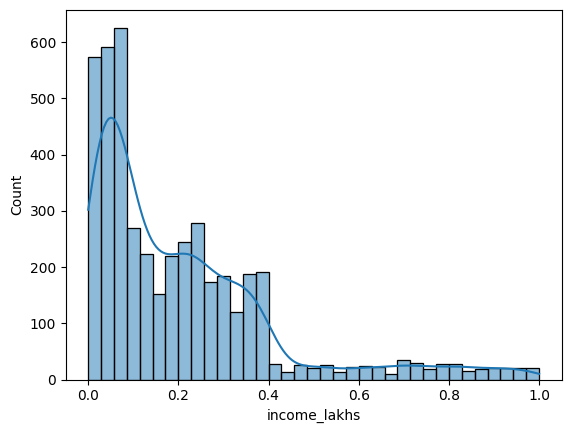

In [71]:
# Plotting the histogram of income_lakhs column
sns.histplot(extreme_errors_df.income_lakhs, kde = True)

Now even after seeing this histogram we can't get any insights out of it. Now If I want to find the feature which actually has the problem then I need to plot side by side histogram of extreme error and X test both.

If both the distribution patterns are simillar then there is no problem but if they are different then there is problem in that perticuler feature. So let's check all the features to find out root cause.

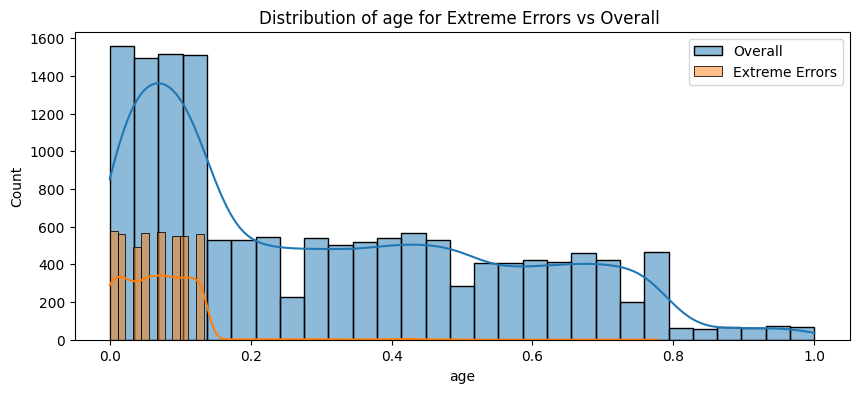

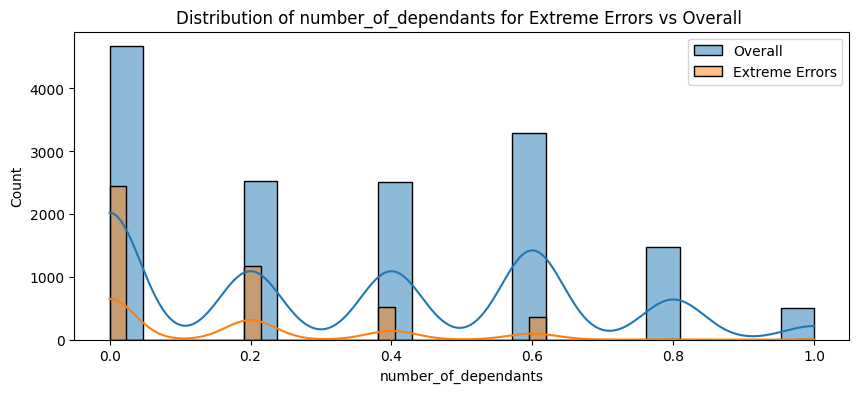

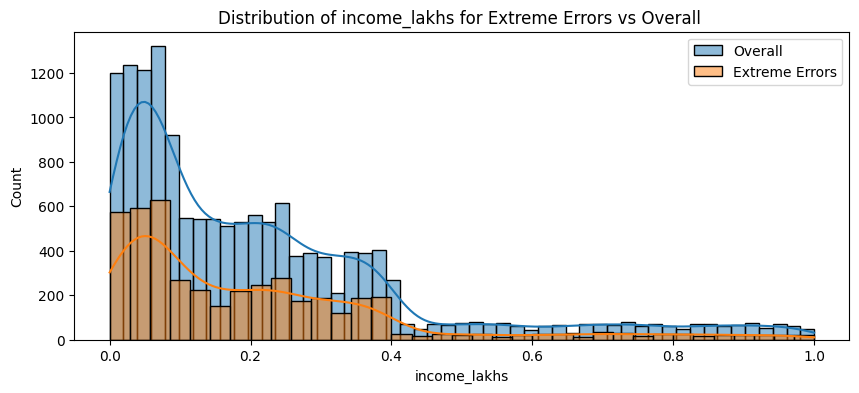

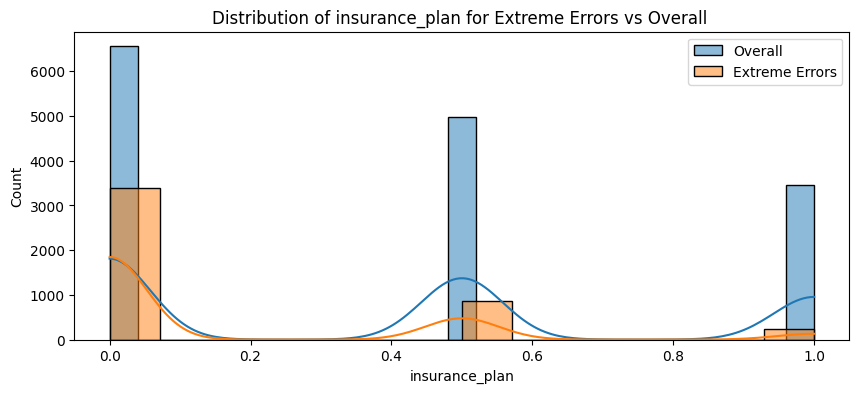

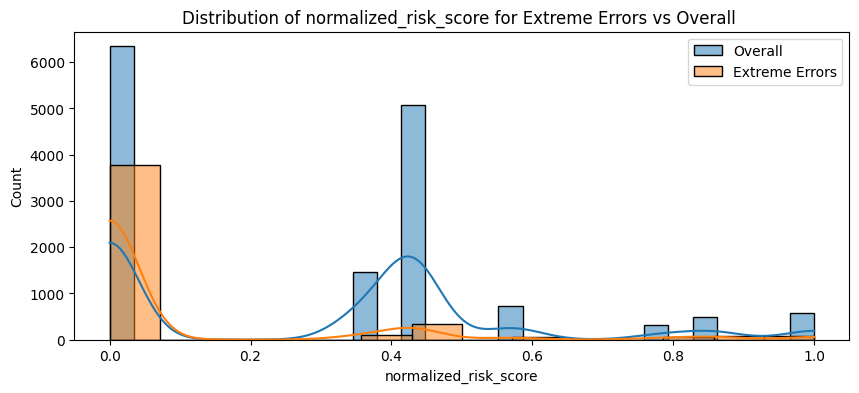

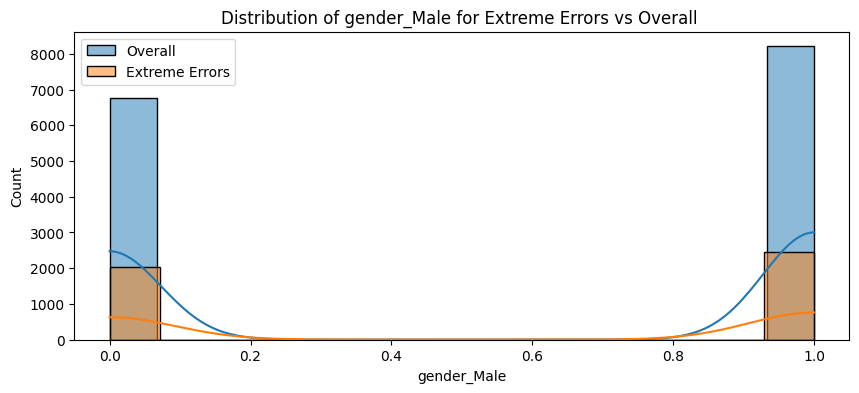

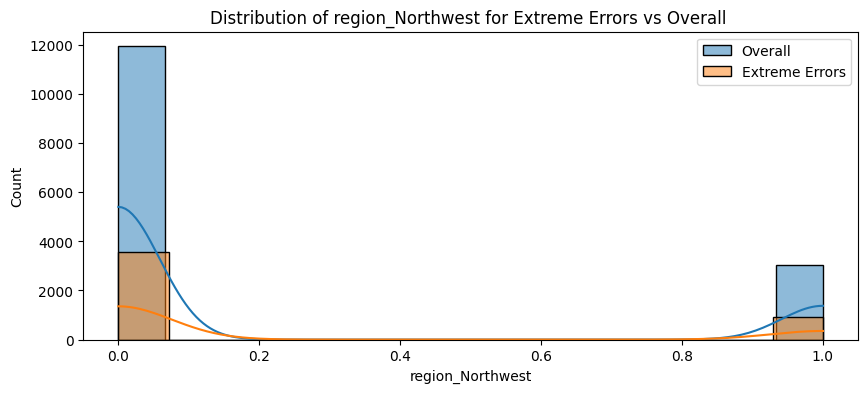

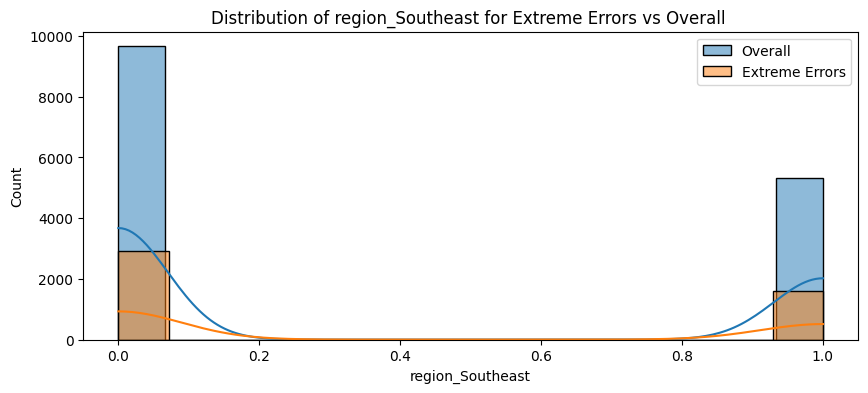

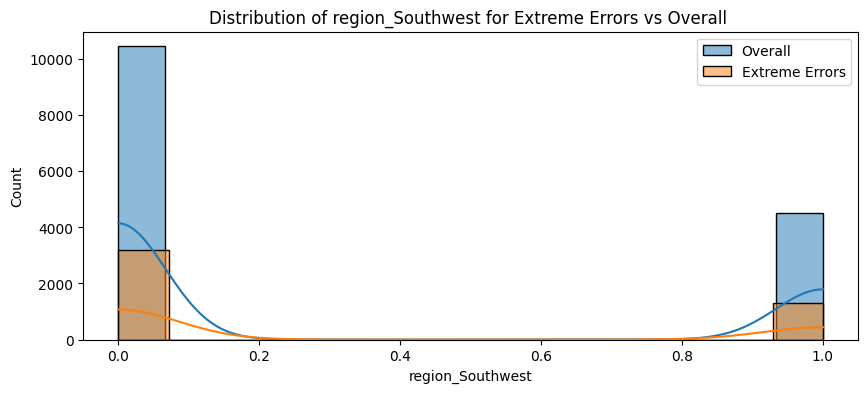

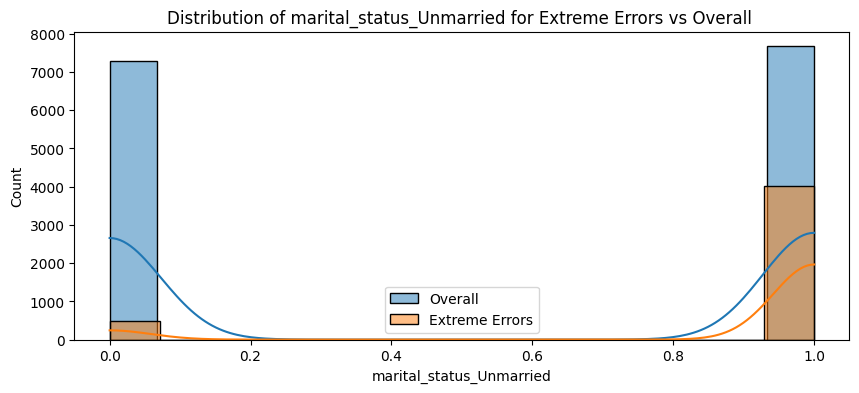

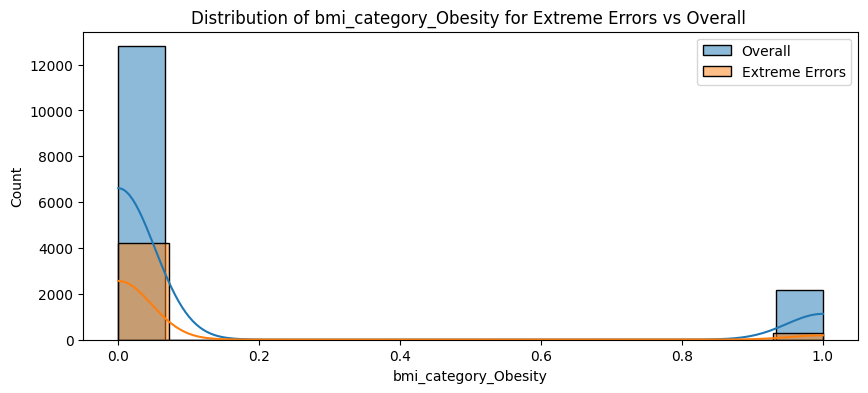

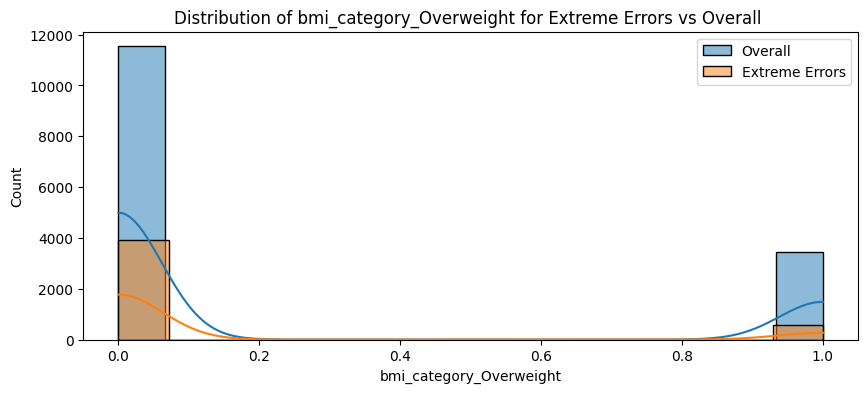

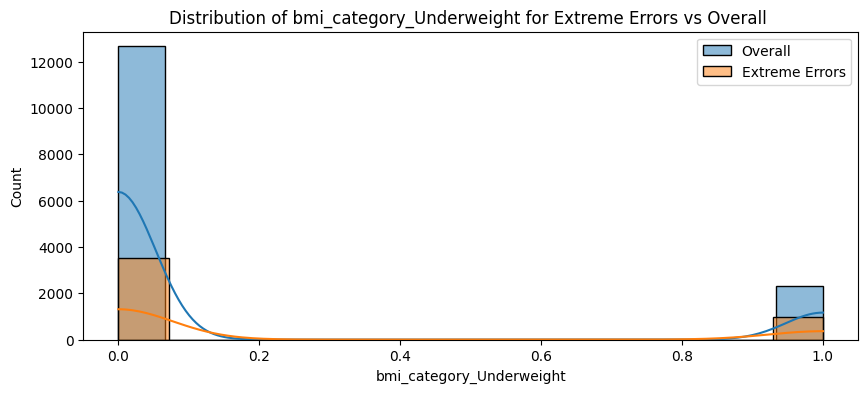

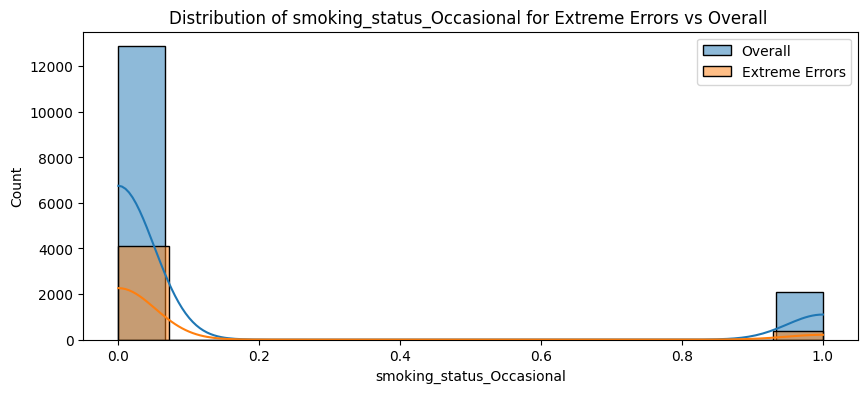

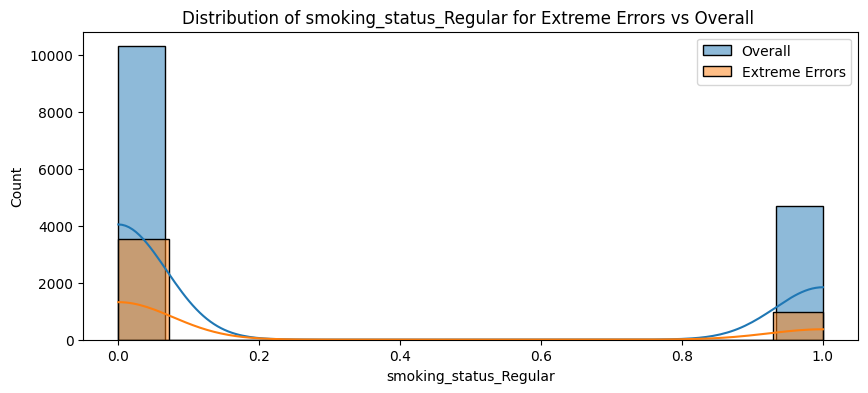

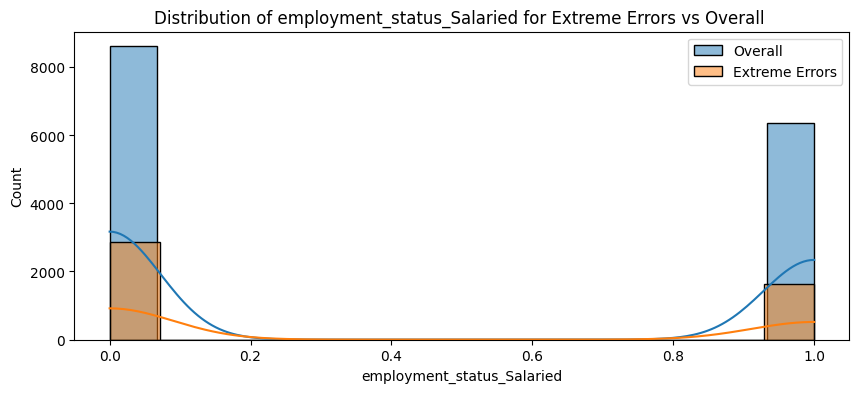

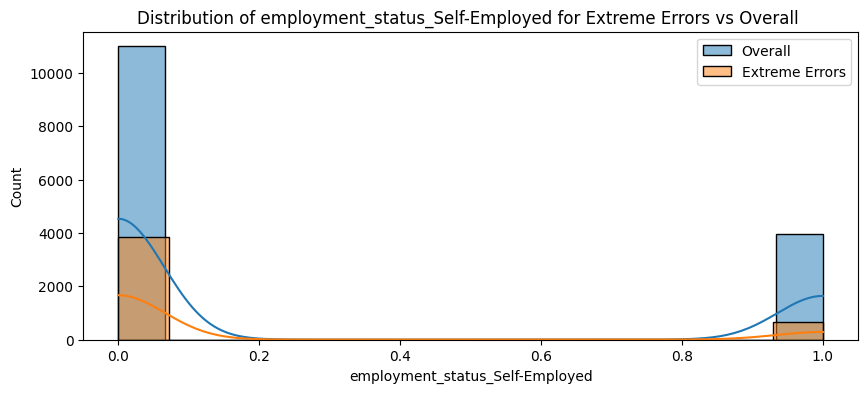

In [72]:
for feature in X_test.columns:
    plt.figure(figsize = (10,4))
    sns.histplot(X_test[feature], label = 'Overall', kde = True)
    sns.histplot(extreme_errors_df[feature], label = 'Extreme Errors' ,kde = True)
    plt.title(f'Distribution of {feature} for Extreme Errors vs Overall ')
    plt.legend()
    plt.show()

As you can see here all other histograms kde pattern looks identical except age column. Like lower age group has more error than other age values.

So we found the actual problem, that is in age column and especially in lower age group. Let's analyze it closly by plotting age's extreme errors graph alone.

<Axes: xlabel='age', ylabel='Count'>

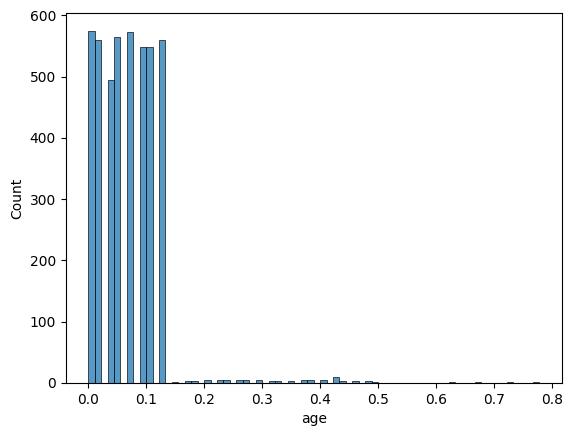

In [73]:
sns.histplot(extreme_errors_df.age)

Now as this column is scaled we are not able to judge that which age values are actually causing the errors. So let's create df_reversed which will be scaled back version of our current extreme_errors_df.

In [74]:
cols_to_scale

['age',
 'number_of_dependants',
 'income_level',
 'income_lakhs',
 'insurance_plan']

In [75]:
# We have to introduce income_level column in our extreme_erros_df because we droppped it using VIF
extreme_errors_df['income_level'] = -1

In [76]:
df_reversed = pd.DataFrame() # Creating new data frame
df_reversed[cols_to_scale] = scaler.inverse_transform(extreme_errors_df[cols_to_scale])
df_reversed

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
0,23.0,1.0,-2.0,14.0,1.0
1,19.0,1.0,-2.0,4.0,1.0
2,18.0,1.0,-2.0,3.0,1.0
3,21.0,0.0,-2.0,25.0,1.0
4,24.0,1.0,-2.0,8.0,2.0
...,...,...,...,...,...
4493,19.0,1.0,-2.0,8.0,1.0
4494,25.0,0.0,-2.0,12.0,1.0
4495,21.0,0.0,-2.0,7.0,2.0
4496,21.0,1.0,-2.0,8.0,1.0


So this is our extreme errors data frame which is scaled back to it's original form. Let's visualize age column in this now to get the actual range.

<Axes: xlabel='age', ylabel='Count'>

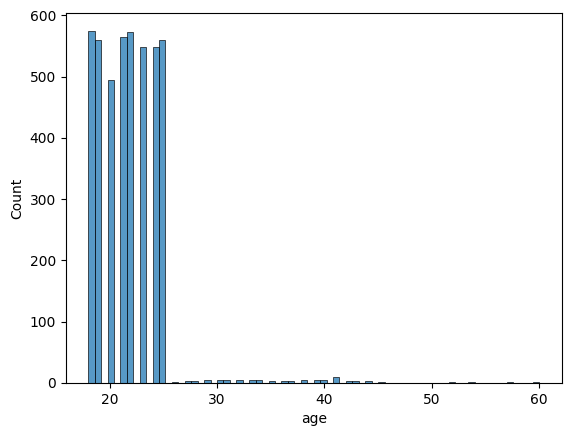

In [77]:
sns.histplot(df_reversed.age)

In [78]:
df_reversed.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
count,4498.000000,4498.00000,4498.0,4498.000000,4498.000000
mean,21.755892,0.73566,-2.0,21.200978,1.300133
std,3.135299,0.96396,0.0,20.603990,0.562488
min,18.000000,0.00000,-2.0,1.000000,1.000000
25%,19.000000,0.00000,-2.0,6.000000,1.000000
50%,22.000000,0.00000,-2.0,15.000000,1.000000
75%,24.000000,1.00000,-2.0,30.000000,1.000000
max,60.000000,5.00000,-2.0,100.000000,3.000000


In [79]:
df_reversed.age.quantile(0.98)

25.0

As we can clearly see that 98% of the records in extreme errors dataframe are age from 18-25 range. So in that age group there is some problem which is causing these extreme errors of more than 10% difference.

So we have to train the young age group sepereatly and rest of the age group sepereatly. Either with the same algorithm(XGBoost) or some different algorithem, which ever gives highest score.

In [85]:
for col in categorical_columns:
    print(col, df2[col].unique())

gender ['Male' 'Female']
region ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status ['Unmarried' 'Married']
bmi_category ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status ['No Smoking' 'Regular' 'Occasional']
employment_status ['Salaried' 'Self-Employed' 'Freelancer']
income_level [1 2 4 3]
medical_history ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan [1 2 3]


In [86]:
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,1,6,Diabetes,1,9053,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,1,6,Diabetes,1,16339,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,2,20,High blood pressure,2,18164,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,4,77,No Disease,3,20303,no disease,none,0,0.000000
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,4,99,High blood pressure,2,13365,high blood pressure,none,6,0.428571


In [87]:
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [89]:
df2.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk_score,normalized_risk_score
count,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000
mean,34.401579,1.717640,2.097700,22.889897,1.794802,15765.739641,4.085638,0.291831
std,13.681604,1.492032,1.049133,22.170699,0.784919,8418.674061,4.023878,0.287420
min,18.000000,0.000000,1.000000,1.000000,1.000000,3501.000000,0.000000,0.000000
25%,22.000000,0.000000,1.000000,7.000000,1.000000,8608.000000,0.000000,0.000000
50%,31.000000,2.000000,2.000000,17.000000,2.000000,13928.000000,5.000000,0.357143
75%,45.000000,3.000000,3.000000,31.000000,2.000000,22270.500000,6.000000,0.428571
max,72.000000,5.000000,4.000000,100.000000,3.000000,43471.000000,14.000000,1.000000
